# Sentence embedding clusters by IR section

This notebook compares one skill document with one deterministic BABILong 8k prompt. It calls Alexandria's `represent()` and works only with sentence embeddings stored in the resulting IR. UMAP produces a clustering space and a two-dimensional view; HDBSCAN assigns cluster labels. In the main view, color always means the sentence's deepest containing IR section.

In [1]:
import os
import sys
from collections import Counter
from importlib import import_module
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv
from hdbscan import HDBSCAN
from matplotlib.lines import Line2D
from umap import UMAP

from alexandria.ir.document import Document, Section, Sentence
from alexandria.ops.features.represent import represent


def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src/alexandria").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from the Alexandria checkout.")


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT))
load_cases = import_module("benchmarks.babilong_8k.cases").load_cases
load_dotenv(REPO_ROOT / ".env")
RANDOM_SEED = 42
print(f"repository: {REPO_ROOT.name}")

repository: alexandria-embedding-clusters


## Load the two inputs

`load_cases(n=1, seed=42)` selects one task-balanced benchmark case reproducibly. The downloaded benchmark data is intentionally git-ignored; run the downloader shown in `notebooks/README.md` before this cell.

In [2]:
default_skill_path = (
    REPO_ROOT.parent / "skill-corpus/corpus/obra__superpowers/skills/subagent-driven-development/SKILL.md"
)
skill_path = Path(os.environ.get("ALEXANDRIA_SKILL_PATH", default_skill_path)).expanduser()
data_dir = REPO_ROOT / "data/babilong/8k"

if not skill_path.is_file():
    raise FileNotFoundError(f"Skill file not found at {skill_path}. Set ALEXANDRIA_SKILL_PATH to its absolute path.")
if not (data_dir / "qa1.json").is_file():
    raise FileNotFoundError("BABILong data is missing. Run `uv run python -m scripts.download_babilong_8k_data`.")

skill_text = skill_path.read_text(encoding="utf-8")
benchmark_case = load_cases(n=1, seed=RANDOM_SEED, data_dir=data_dir)[0]
inputs = {
    "skill": skill_text,
    f"babilong {benchmark_case.key}": benchmark_case.prompt,
}

print(f"skill: {Path(*skill_path.parts[-4:])}")
print(f"benchmark case: {benchmark_case.key} ({benchmark_case.task})")
print({name: len(text) for name, text in inputs.items()})

skill: obra__superpowers/skills/subagent-driven-development/SKILL.md
benchmark case: qa1:42 (qa1)
{'skill': 21540, 'babilong qa1:42': 31424}


## Build Alexandria IR

No embedding client is created in the notebook. Omitting `embedder` delegates to Alexandria's default `text-embedding-3-small` implementation, and the following analysis reads each vector from `Document.sentences`.

In [3]:
documents = {name: represent(text) for name, text in inputs.items()}
for name, document in documents.items():
    print(
        f"{name}: {len(document.sentences)} sentences, "
        f"{len(document.sections)} root sections, model={document.embedding_model}"
    )

skill: 396 sentences, 2 root sections, model=text-embedding-3-small
babilong qa1:42: 686 sentences, 6 root sections, model=text-embedding-3-small


## Preserve the sentence-to-section relationship

A sentence inherits the deepest `Section` that directly contains it. The index path disambiguates repeated XML tags such as `<example>`.

In [4]:
def sentence_rows(document: Document, source: str) -> list[dict[str, object]]:
    rows: list[dict[str, object]] = []

    def visit(section: Section, path: tuple[int, ...]) -> None:
        section_name = section.header.strip() or section.kind.value
        path_label = ".".join(str(part) for part in path)
        section_label = f"{source} / {section_name} [{path_label}]"
        nested_index = 0
        for child in section.children:
            if isinstance(child, Sentence):
                rows.append(
                    {
                        "source": source,
                        "section": section_label,
                        "sentence_id": str(child.id),
                        "text": child.text.strip(),
                        "optimizable": child.optimizable,
                        "embedding": child.embedding,
                    }
                )
            else:
                nested_index += 1
                visit(child, (*path, nested_index))

    for root_index, section in enumerate(document.sections, start=1):
        visit(section, (root_index,))
    return rows


rows = [row for source, document in documents.items() for row in sentence_rows(document, source)]
embeddings = np.stack([row["embedding"] for row in rows])
section_counts = Counter(str(row["section"]) for row in rows)

print(f"embedding matrix: {embeddings.shape}")
print(f"deepest sections: {len(section_counts)}")
for section, count in section_counts.items():
    print(f"{count:>4}  {section}")

embedding matrix: (1082, 1536)
deepest sections: 22
   4  skill / plain [1]
  14  skill / Subagent-Driven Development [2]
  33  skill / When to Use [2.1]
  44  skill / The Process [2.2]
  11  skill / Pre-Flight Plan Review [2.3]
  28  skill / Model Selection [2.4]
  18  skill / Handling Implementer Status [2.5]
   8  skill / Handling Reviewer ⚠️ Items [2.6]
  65  skill / Constructing Reviewer Prompts [2.7]
  29  skill / File Handoffs [2.8]
  21  skill / Durable Progress [2.9]
   4  skill / Prompt Templates [2.10]
  47  skill / Example Workflow [2.11]
  26  skill / Advantages [2.12]
  34  skill / Red Flags [2.13]
  10  skill / Integration [2.14]
   3  babilong qa1:42 / plain [1]
   7  babilong qa1:42 / example [2]
   8  babilong qa1:42 / example [3]
   2  babilong qa1:42 / plain [4]
 665  babilong qa1:42 / context [5]
   1  babilong qa1:42 / plain [6]


## UMAP + HDBSCAN

Clustering uses a 10-dimensional UMAP space (`cosine`, `min_dist=0`) rather than the display coordinates. A separate two-dimensional UMAP is used only for plotting. Both reducers share a fixed seed. HDBSCAN uses leaf selection to expose finer local groups instead of collapsing the two source documents into two coarse clusters.

In [5]:
n_neighbors = min(30, len(rows) - 1)
cluster_space = UMAP(
    n_components=10,
    n_neighbors=n_neighbors,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_SEED,
    n_jobs=1,
).fit_transform(embeddings)
plot_space = UMAP(
    n_components=2,
    n_neighbors=n_neighbors,
    min_dist=0.1,
    metric="cosine",
    random_state=RANDOM_SEED,
    n_jobs=1,
).fit_transform(embeddings)

min_cluster_size = max(20, len(rows) // 36)
cluster_labels = HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=3,
    metric="euclidean",
    cluster_selection_method="leaf",
).fit_predict(cluster_space)

cluster_counts = Counter(int(label) for label in cluster_labels)
print(f"selection=leaf, min_cluster_size={min_cluster_size}, min_samples=3")
print(f"clusters={len(cluster_counts) - (-1 in cluster_counts)}, noise={cluster_counts.get(-1, 0)}")

selection=leaf, min_cluster_size=30, min_samples=3
clusters=8, noise=320


In [6]:
for label in sorted(cluster_counts):
    mask = cluster_labels == label
    members = [rows[index] for index in np.flatnonzero(mask)]
    dominant_section, dominant_count = Counter(str(member["section"]) for member in members).most_common(1)[0]
    name = "noise" if label == -1 else f"cluster {label}"
    print(f"{name:>10}: n={len(members):>4}, dominant={dominant_count / len(members):.1%} {dominant_section}")

     noise: n= 320, dominant=71.6% babilong qa1:42 / context [5]
 cluster 0: n=  58, dominant=22.4% skill / When to Use [2.1]
 cluster 1: n=  61, dominant=21.3% skill / The Process [2.2]
 cluster 2: n=  57, dominant=15.8% skill / Durable Progress [2.9]
 cluster 3: n= 141, dominant=29.8% skill / Constructing Reviewer Prompts [2.7]
 cluster 4: n=  89, dominant=100.0% babilong qa1:42 / context [5]
 cluster 5: n=  65, dominant=100.0% babilong qa1:42 / context [5]
 cluster 6: n= 138, dominant=100.0% babilong qa1:42 / context [5]
 cluster 7: n= 153, dominant=92.2% babilong qa1:42 / context [5]


## Two-dimensional view

Panels A and B contain exactly the same sentences at exactly the same UMAP coordinates; only the meaning of color changes. Panel A uses the known IR section membership, while panel B uses the unsupervised HDBSCAN result. Panel C directly compares them: each row sums to 100%, so a section concentrated in one or two columns is more internally cohesive than a section spread across many clusters. Gray points and the `noise` column are sentences that HDBSCAN deliberately leaves unassigned.

wrote notebooks/outputs/section_embedding_clusters.png


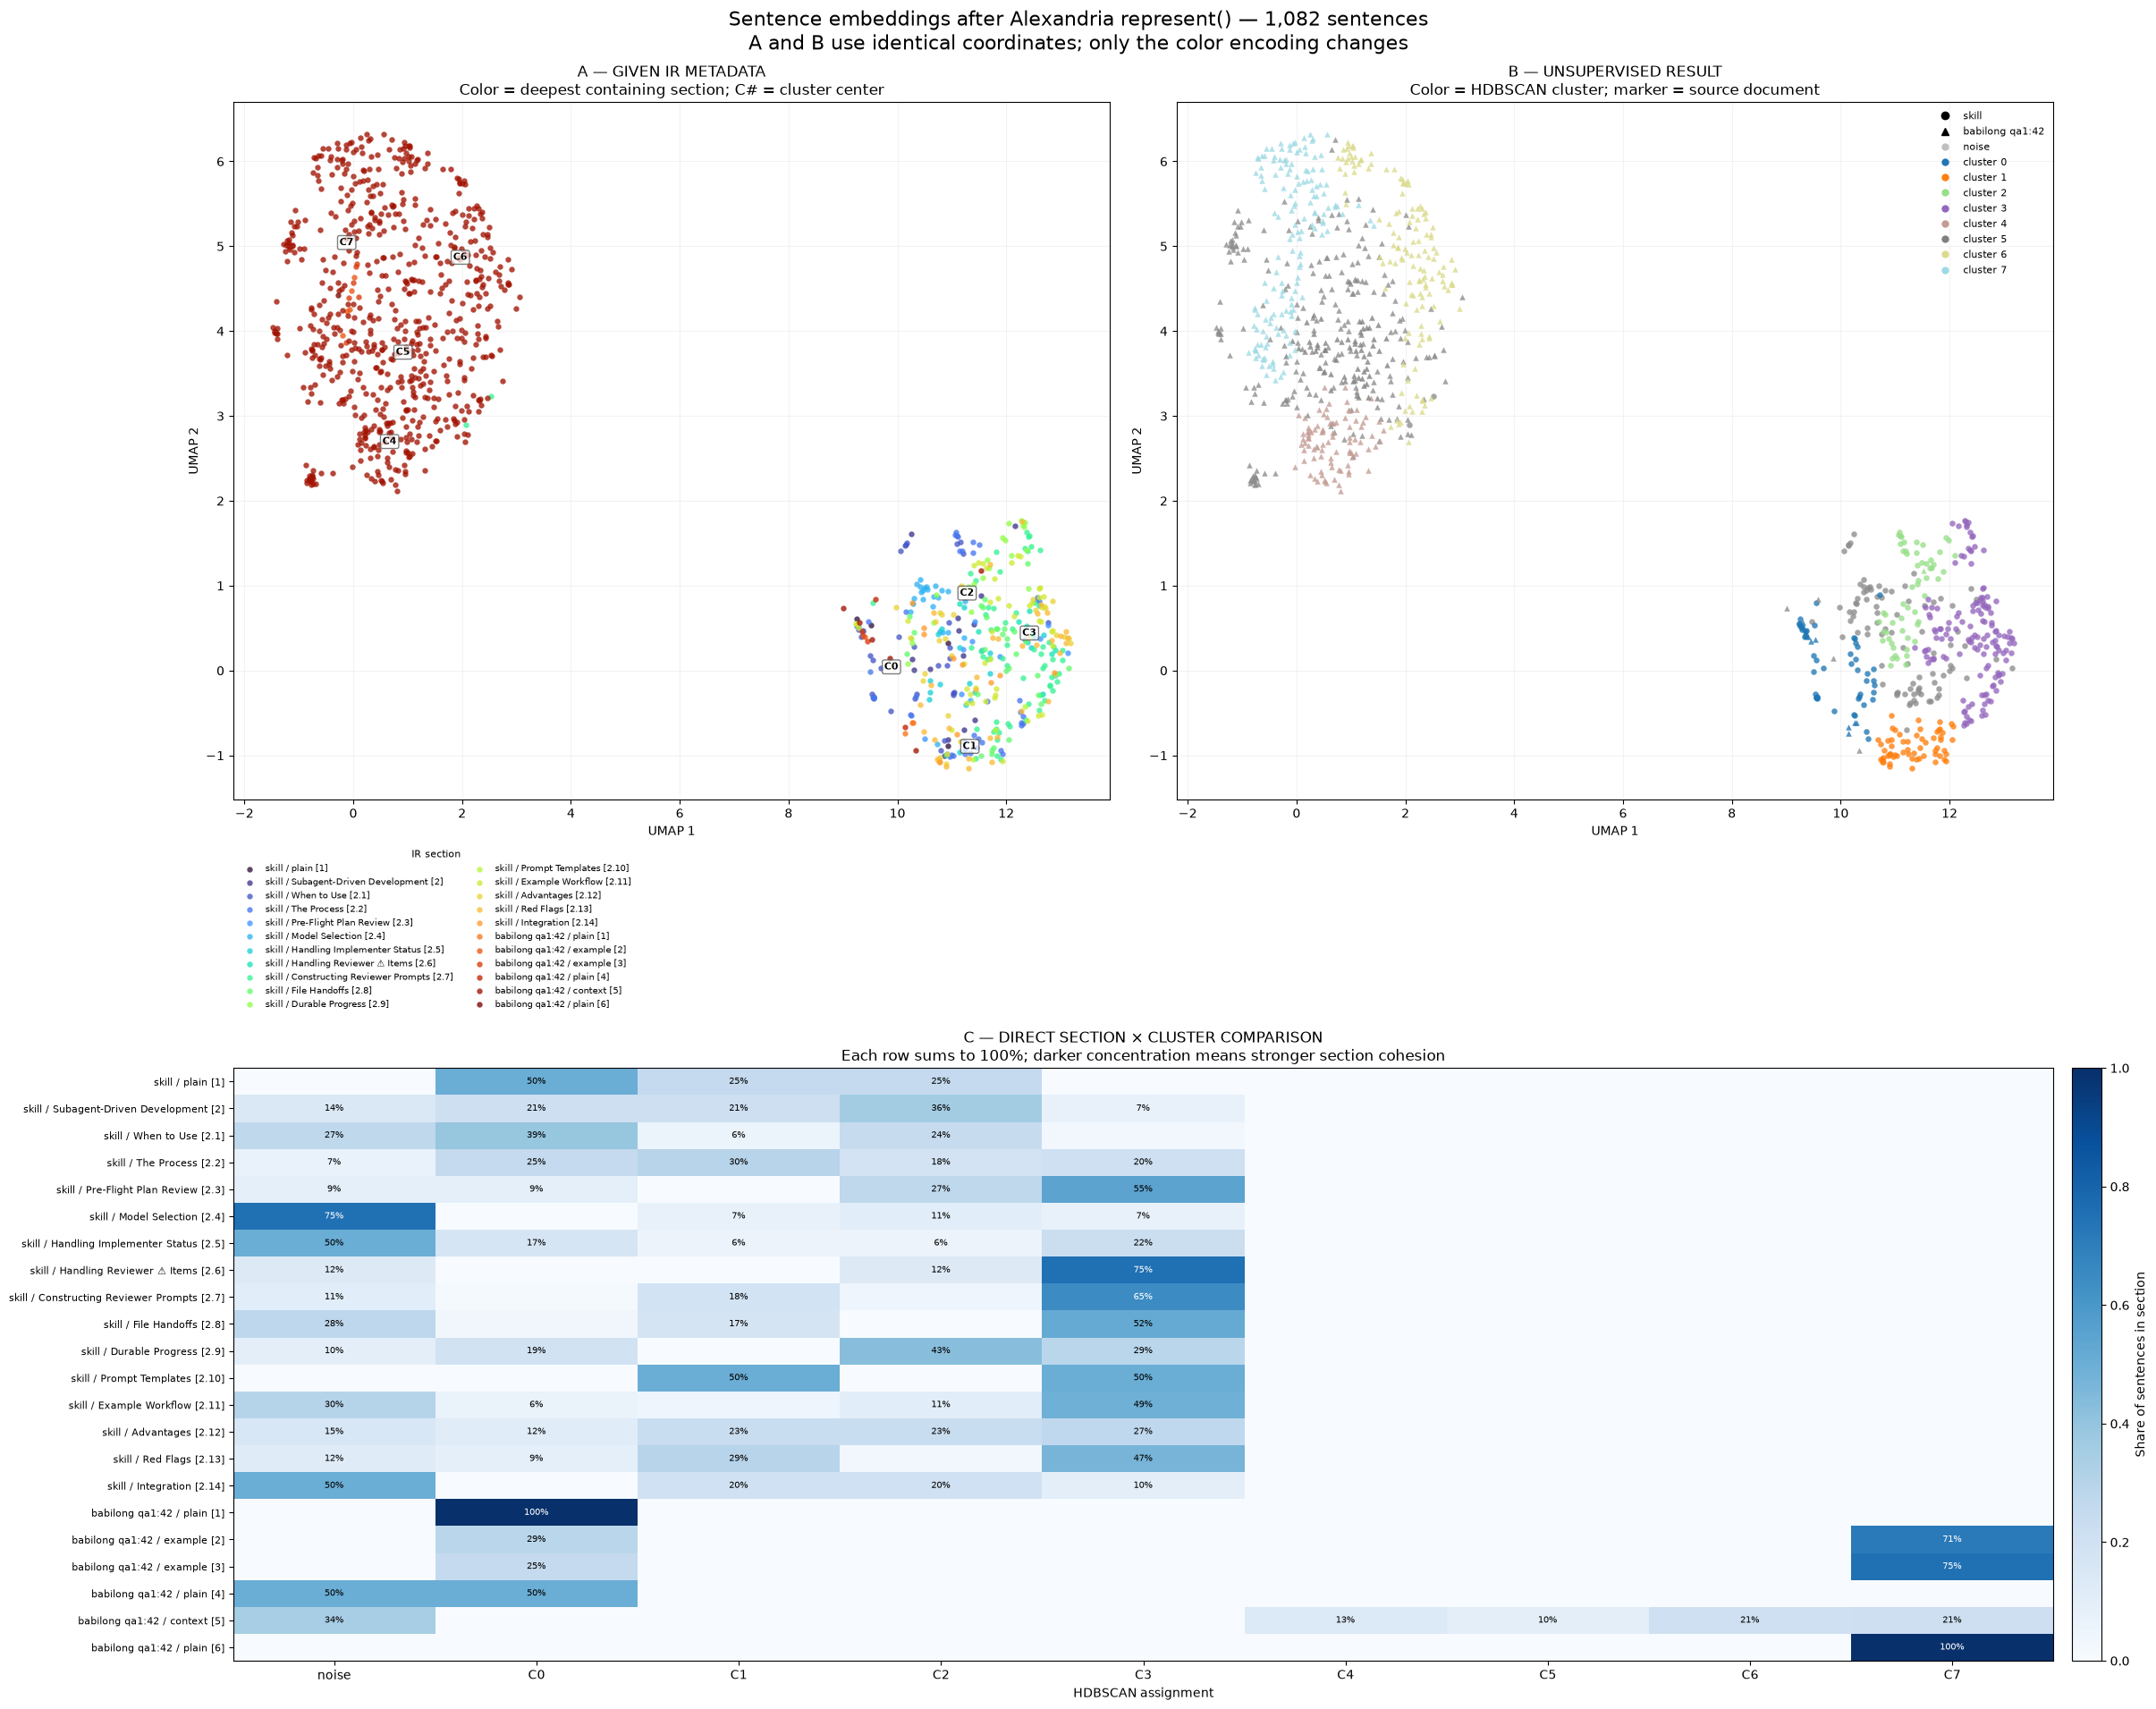

In [7]:
section_names = list(section_counts)
section_cmap = plt.colormaps["turbo"].resampled(len(section_names))
section_colors = {name: section_cmap(index) for index, name in enumerate(section_names)}
cluster_ids = sorted(label for label in cluster_counts if label != -1)
cluster_cmap = plt.colormaps["tab20"].resampled(max(1, len(cluster_ids)))
cluster_colors = {label: cluster_cmap(index) for index, label in enumerate(cluster_ids)}
cluster_colors[-1] = (0.55, 0.55, 0.55, 0.55)
source_markers = dict(zip(documents, ("o", "^"), strict=True))

fig = plt.figure(figsize=(24, 19), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=(1.0, 0.85))
axes = (fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1]))
heatmap_axis = fig.add_subplot(grid[1, :])

for section_name in section_names:
    mask = np.array([row["section"] == section_name for row in rows])
    axes[0].scatter(
        plot_space[mask, 0],
        plot_space[mask, 1],
        s=21,
        alpha=0.78,
        color=section_colors[section_name],
        label=section_name,
        linewidths=0,
    )
for label in cluster_ids:
    center = plot_space[cluster_labels == label].mean(axis=0)
    axes[0].annotate(
        f"C{label}",
        center,
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        bbox={"boxstyle": "round,pad=0.2", "fc": "white", "alpha": 0.72, "ec": "0.3"},
    )
axes[0].set_title("A — GIVEN IR METADATA\nColor = deepest containing section; C# = cluster center")
axes[0].legend(
    title="IR section",
    loc="upper left",
    bbox_to_anchor=(0, -0.06),
    fontsize=7,
    title_fontsize=8,
    ncol=2,
    frameon=False,
)

for source, marker in source_markers.items():
    source_mask = np.array([row["source"] == source for row in rows])
    for label in sorted(cluster_counts):
        mask = source_mask & (cluster_labels == label)
        if mask.any():
            axes[1].scatter(
                plot_space[mask, 0],
                plot_space[mask, 1],
                s=22,
                alpha=0.78,
                marker=marker,
                color=cluster_colors[label],
                linewidths=0,
            )
cluster_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=cluster_colors[label],
        markeredgecolor="none",
        label="noise" if label == -1 else f"cluster {label}",
    )
    for label in sorted(cluster_counts)
]
source_handles = [
    Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="",
        color="black",
        label=source,
    )
    for source, marker in source_markers.items()
]
axes[1].set_title("B — UNSUPERVISED RESULT\nColor = HDBSCAN cluster; marker = source document")
axes[1].legend(
    handles=[*source_handles, *cluster_handles],
    loc="best",
    fontsize=8,
    frameon=False,
)

for axis in axes:
    axis.set_xlabel("UMAP 1")
    axis.set_ylabel("UMAP 2")
    axis.grid(alpha=0.15)

heatmap_labels = ([-1] if -1 in cluster_counts else []) + cluster_ids
section_cluster_share = np.zeros((len(section_names), len(heatmap_labels)))
for section_index, section_name in enumerate(section_names):
    section_mask = np.array([row["section"] == section_name for row in rows])
    for cluster_index, label in enumerate(heatmap_labels):
        section_cluster_share[section_index, cluster_index] = np.mean(cluster_labels[section_mask] == label)
heatmap = heatmap_axis.imshow(section_cluster_share, aspect="auto", cmap="Blues", vmin=0, vmax=1)
heatmap_axis.set_xticks(
    range(len(heatmap_labels)),
    ["noise" if label == -1 else f"C{label}" for label in heatmap_labels],
)
heatmap_axis.set_yticks(range(len(section_names)), section_names, fontsize=8)
heatmap_axis.set_xlabel("HDBSCAN assignment")
heatmap_axis.set_title(
    "C — DIRECT SECTION × CLUSTER COMPARISON\n"
    "Each row sums to 100%; darker concentration means stronger section cohesion"
)
for section_index in range(len(section_names)):
    for cluster_index in range(len(heatmap_labels)):
        share = section_cluster_share[section_index, cluster_index]
        if share >= 0.05:
            heatmap_axis.text(
                cluster_index,
                section_index,
                f"{share:.0%}",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if share >= 0.55 else "black",
            )
colorbar = fig.colorbar(heatmap, ax=heatmap_axis, fraction=0.02, pad=0.01)
colorbar.set_label("Share of sentences in section")

fig.suptitle(
    f"Sentence embeddings after Alexandria represent() — {len(rows):,} sentences\n"
    "A and B use identical coordinates; only the color encoding changes",
    fontsize=16,
)
output_path = REPO_ROOT / "notebooks/outputs/section_embedding_clusters.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=180, bbox_inches="tight")
print(f"wrote {output_path.relative_to(REPO_ROOT)}")
plt.show()